# EDA 02 — Distributions and Missingness

Second step of the EDA stage. Groups the predictors by distribution shape (which decides
the transformation each one needs), surfaces the zero-spike on open credit lines, and
shows that income missingness is not random but rises monotonically with age. The
age-conditional imputation fitted in Fitting 01 follows directly from this finding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# Paths and column rename map (same convention as EDA 01).
DATA_PATH = "../data/cs-training.csv"
RENAME = {
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilisation",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "past_due_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines_and_loans",
    "NumberOfTimes90DaysLate": "past_due_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans_or_lines",
    "NumberOfTime60-89DaysPastDueNotWorse": "past_due_60_89",
    "NumberOfDependents": "dependents",
}

In [3]:
# Load and rename. The sentinel codes (96/98) are temporarily replaced by each column's
# legitimate maximum + 1 so they do not distort the shape statistics computed below; the
# definitive, train-only recoding happens in Fitting 01.
df = pd.read_csv(DATA_PATH, index_col=0).rename(columns=RENAME)
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    legit_max = df.loc[~df[col].isin([96, 98]), col].max()
    df[col] = df[col].replace({96: legit_max + 1, 98: legit_max + 1})
print(f"rows: {len(df):,} - sentinels recoded for exploration")

rows: 150,000 - sentinels recoded for exploration


In [4]:
# Shape statistics per predictor. Three features are extremely heavy-tailed (skewness in
# the tens), age is near-symmetric, and the remaining features are small-range counts.
# This taxonomy drives the per-feature treatment: heavy tails get capped and transformed,
# age and the counts are left on their natural scale.
features = [c for c in df.columns if c != "target"]
shape = pd.DataFrame({
    "skewness": df[features].skew(),
    "kurtosis": df[features].kurt(),
}).sort_values("skewness", ascending=False)
shape.round(2)

,skewness,kurtosis
monthly_income,114.04,19504.71
revolving_utilisation,97.63,14544.71
debt_ratio,95.16,13734.29
past_due_90,15.50,288.12
past_due_60_89,15.03,277.87
past_due_30_59,8.07,100.44
real_estate_loans_or_lines,3.48,60.48
dependents,1.59,3.00
open_credit_lines_and_loans,1.22,3.09
age,0.19,-0.49


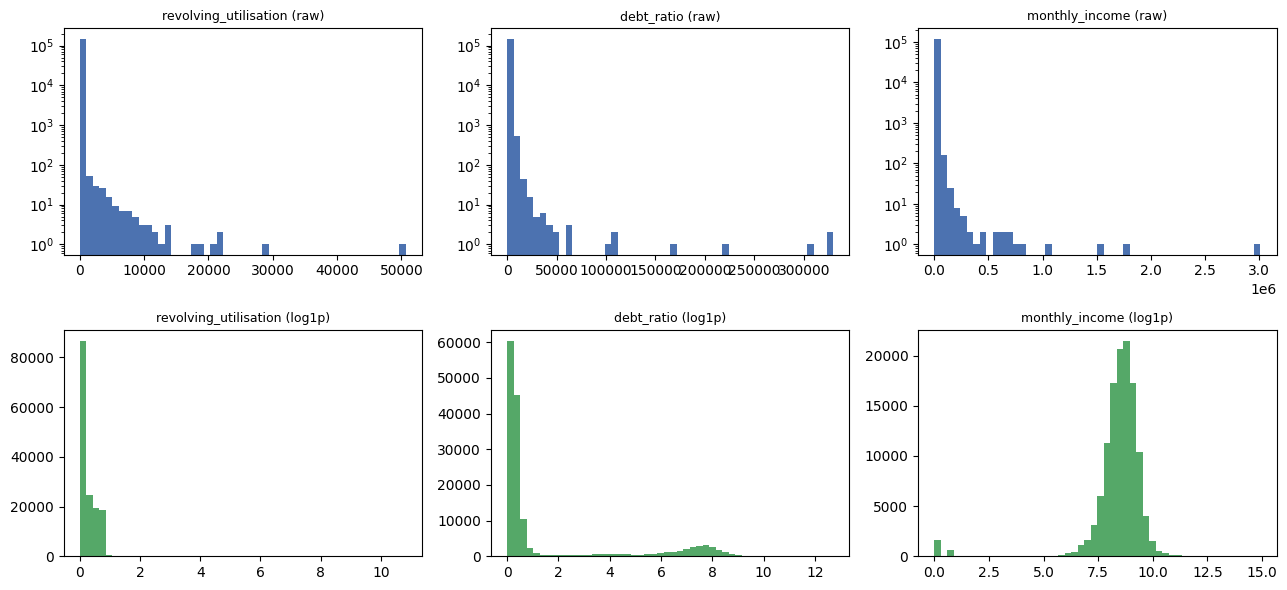

In [5]:
# Visual check of the three heavy-tailed features before and after a log1p transform.
# The raw scale is unusable for a linear model; log1p makes the bulk of the distribution
# visible. The formal transformation choice per feature is made in EDA 03.
heavy = ["revolving_utilisation", "debt_ratio", "monthly_income"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, col in enumerate(heavy):
    x = df[col].dropna()
    axes[0, j].hist(x, bins=50, color="#4C72B0")
    axes[0, j].set_yscale("log")
    axes[0, j].set_title(f"{col} (raw)", fontsize=9)
    axes[1, j].hist(np.log1p(x), bins=50, color="#55A868")
    axes[1, j].set_title(f"{col} (log1p)", fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# Zero-spike on open credit lines: borrowers with no open credit line at all default at
# ~26%, four times the baseline. A zero count is therefore informative on its own, which
# motivates the zero_flag_open_credit_lines candidate feature in EDA 04.
zero_mask = df["open_credit_lines_and_loans"] == 0
pd.DataFrame({
    "rows": [int(zero_mask.sum()), int((~zero_mask).sum())],
    "default_rate": [df.loc[zero_mask, "target"].mean(),
                     df.loc[~zero_mask, "target"].mean()],
}, index=["zero open credit lines", "one or more"]).round(4)

,rows,default_rate
zero open credit lines,1888,0.2564
one or more,148112,0.0644


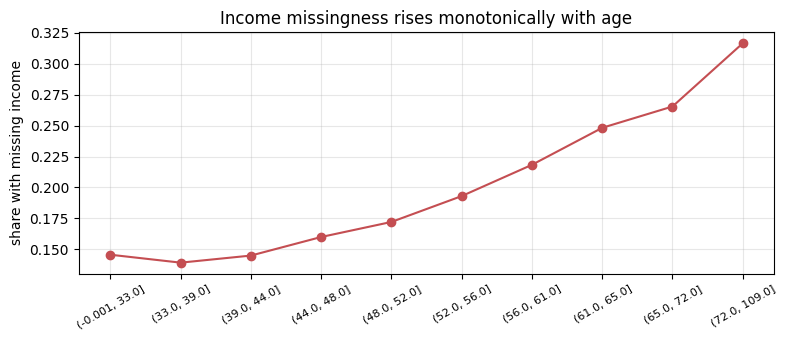

,missing_rate,n
age_decile,,
"(-0.001, 33.0]",0.1456,17085
"(33.0, 39.0]",0.1392,14919
"(39.0, 44.0]",0.1449,15799
"(44.0, 48.0]",0.1600,14741
"(48.0, 52.0]",0.1721,14826
"(52.0, 56.0]",0.1930,14214
"(56.0, 61.0]",0.2183,16878
"(61.0, 65.0]",0.2482,12939
"(65.0, 72.0]",0.2655,14258


In [7]:
# Income missingness by age decile. The missing rate rises monotonically from ~15% for
# the youngest borrowers to ~32% for the oldest - consistent with retired borrowers being
# less likely to report an income. Missingness therefore depends on an observed variable
# (age), i.e. the mechanism is missing-at-random conditional on age, not random.
df["missing_income"] = df["monthly_income"].isna().astype(int)
df["age_decile"] = pd.qcut(df["age"], 10, duplicates="drop")
by_decile = df.groupby("age_decile", observed=True)["missing_income"].agg(["mean", "count"])
by_decile.columns = ["missing_rate", "n"]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(len(by_decile)), by_decile["missing_rate"], marker="o", color="#C44E52")
ax.set_xticks(range(len(by_decile)))
ax.set_xticklabels([str(i) for i in by_decile.index], rotation=30, fontsize=8)
ax.set_ylabel("share with missing income")
ax.set_title("Income missingness rises monotonically with age")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
by_decile.round(4)

In [8]:
# Formal test that missingness is not random: a chi-square test of independence between
# the missing-income flag and the age decile. The hypothesis of independence is rejected
# overwhelmingly, confirming the age-conditional mechanism. (The thesis report uses
# Little's MCAR test, a stricter multivariate version; both reach the same conclusion.)
table = pd.crosstab(df["age_decile"], df["missing_income"])
chi2, p_value, dof, _ = chi2_contingency(table)
print(f"chi-square = {chi2:,.0f}   df = {dof}   p-value = {p_value:.3g}")
print("conclusion: income missingness depends on age -> impute income per age group")

chi-square = 3,024   df = 9   p-value = 0
conclusion: income missingness depends on age -> impute income per age group


In [9]:
# Default rate when income is missing vs observed. Counter-intuitively the missing-income
# group defaults slightly LESS - because missingness concentrates among older, lower-risk
# borrowers. This age confound is why the missing-income flag adds almost no predictive
# signal on its own (confirmed in EDA 04) even though the mechanism is systematic.
pd.DataFrame({
    "rows": [int(df["missing_income"].sum()), int((1 - df["missing_income"]).sum())],
    "default_rate": [df.loc[df["missing_income"] == 1, "target"].mean(),
                     df.loc[df["missing_income"] == 0, "target"].mean()],
}, index=["income missing", "income observed"]).round(4)

,rows,default_rate
income missing,29731,0.0561
income observed,120269,0.0695
